## Temporal landing

**Importing Useful Libraries**

In [3]:
import os
import boto3
import pandas as pd
from PIL import Image
from io import StringIO
import matplotlib.pyplot as plt
from datasets import load_dataset

import kagglehub
from kagglehub import KaggleDatasetAdapter


Since all structured data that we will be using are csv files, in the next cell, we define a function that uploads the given csv file to MinIO.

In [23]:
def uplod_csv(df, bucket_name, object_name, path="temporal-landing/", metadata=None):
    # Convert DataFrame to CSV in memory
    csv_buffer = StringIO()
    df.to_csv(csv_buffer, index=False)

    # Renaming
    object_name = f"{path}{object_name}"
    # Upload CSV to MinIO
    s3.put_object(
        Bucket=bucket_name,
        Key=object_name,
        Body=csv_buffer.getvalue(),
        Metadata=metadata
    )

    print("CSV successfully uploaded to MinIO!")

Here we will mainly store batch data, streaming data are stored elsewhere. In the following cells, we will download each of the batch data and move them to `temporal-landing`, where we store temporal files which are removed after being moved to `persistent-landing`.

**Global Warming Dataset (Structured)**

This dataset provides a detailed exploration of global warming and climate change trends across 195 countries from 1900 to 2023. It includes 100,000 rows and 26 columns, capturing environmental, economic, and societal factors impacting global warming. Key indicators such as temperature anomalies, CO2 emissions, deforestation rates, sea-level rise, and renewable energy usage are also included. Link: `https://www.kaggle.com/datasets/ankushpanday1/global-warming-dataset-195-countries-1900-2023`

In [5]:
gwd_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ankushpanday1/global-warming-dataset-195-countries-1900-2023",
  "global_warming_dataset.csv"
)
print("First 5 records:", gwd_df.head())

C:\Users\Akira\AppData\Local\Temp\ipykernel_42996\4068025393.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  gwd_df = kagglehub.load_dataset(


First 5 records:        Country  Year  Temperature_Anomaly  CO2_Emissions    Population  \
0  Country_103  1913            -1.163537   8.876061e+08  1.627978e+08   
1  Country_180  1950            -0.432122   4.497517e+08  4.281359e+08   
2   Country_93  2014             0.444954   4.579080e+08  4.926732e+08   
3   Country_15  2020            -1.171616   5.049503e+08  1.252169e+09   
4  Country_107  1964            -0.564038   6.898891e+08  2.932960e+08   

   Forest_Area           GDP  Renewable_Energy_Usage  Methane_Emissions  \
0    54.872178  6.139887e+12               76.710013       8.317626e+06   
1    84.051006  2.601447e+12               68.450021       6.206540e+06   
2    72.295357  5.192677e+12               36.725699       1.056885e+06   
3    17.259684  8.252128e+12               77.547901       1.986813e+06   
4    44.438605  8.560746e+12               10.019576       3.313252e+06   

   Sea_Level_Rise  ...  Waste_Management  Per_Capita_Emissions  \
0        8.111839  ..

In [6]:
gwd_df.shape

(100000, 26)

In [10]:
# Upload to MinIO
uplod_csv(gwd_df, "landing-zone", "global_warming_dataset.csv",
    metadata={"source": "kaggle",
              "url": "https://www.kaggle.com/datasets/ankushpanday1/global-warming-dataset-195-countries-1900-2023"}
)

CSV successfully uploaded to MinIO!


**CO2 Emission by Vehicles (Structured)**

This dataset captures the details of how CO2 emissions by a vehicle can vary with the different features. The dataset has been taken from Canada Government official open data website. This is a compiled version. This contains data over a period of 7 years. There are total 7385 rows and 12 columns. There are few abbreviations that has been used to describe the features. Link: `https://www.kaggle.com/datasets/debajyotipodder/co2-emission-by-vehicles`

In [3]:
co2_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "debajyotipodder/co2-emission-by-vehicles",
  "CO2 Emissions_Canada.csv"
)
print("First 5 records:", co2_df.head())

C:\Users\Akira\AppData\Local\Temp\ipykernel_42996\3933518788.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  co2_df = kagglehub.load_dataset(


First 5 records:     Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7                               9.6   
2  

In [11]:
co2_df.shape

(7385, 12)

In [12]:
# Upload to MinIO
uplod_csv(co2_df, "landing-zone", "co2-emission-by-vehicles.csv",
    metadata={"source": "kaggle",
              "url": "https://www.kaggle.com/datasets/debajyotipodder/co2-emission-by-vehicles"}
)

CSV successfully uploaded to MinIO!


**Temperature Change (Structured)**

This dataset from FAOSTAT contains statistics about changes in mean surface temperature by country, updated yearly. It covers the period 1961–2023 and provides monthly, seasonal, and annual temperature anomalies, meaning the temperature difference compared to a baseline climate period from 1951 to 1980. The dataset also includes the standard deviation of the temperature change, which helps measure variability in the data. The information is based on the GISTEMP global temperature dataset produced by the NASA Goddard Institute for Space Studies (NASA-GISS), which tracks global surface temperature changes. Link: `https://www.kaggle.com/datasets/sevgisarac/temperature-change`

In [14]:
# Use dataset_load and specify the encoding in pandas_kwargs
path = kagglehub.dataset_download("sevgisarac/temperature-change")
# 2. Find the CSV file in that folder automatically
files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_path = os.path.join(path, files[0])
# 3. Load with the encoding we identified earlier
tc_df = pd.read_csv(csv_path, encoding="latin-1")
print(f"Loaded file: {files[0]}")
print(tc_df.head())

Loaded file: Environment_Temperature_change_E_All_Data_NOFLAG.csv
   Area Code         Area  Months Code    Months  Element Code  \
0          2  Afghanistan         7001   January          7271   
1          2  Afghanistan         7001   January          6078   
2          2  Afghanistan         7002  February          7271   
3          2  Afghanistan         7002  February          6078   
4          2  Afghanistan         7003     March          7271   

              Element Unit  Y1961  Y1962  Y1963  ...  Y2010  Y2011  Y2012  \
0  Temperature change   °C  0.777  0.062  2.744  ...  3.601  1.179 -0.583   
1  Standard Deviation   °C  1.950  1.950  1.950  ...  1.950  1.950  1.950   
2  Temperature change   °C -1.743  2.465  3.919  ...  1.212  0.321 -3.201   
3  Standard Deviation   °C  2.597  2.597  2.597  ...  2.597  2.597  2.597   
4  Temperature change   °C  0.516  1.336  0.403  ...  3.390  0.748 -0.527   

   Y2013  Y2014  Y2015  Y2016  Y2017  Y2018  Y2019  
0  1.233  1.755  1.94

In [15]:
tc_df.shape

(9656, 66)

In [16]:
# Upload to MinIO
uplod_csv(tc_df, "landing-zone", "temperature_change.csv",
    metadata={"source": "kaggle",
              "url": "https://www.kaggle.com/datasets/sevgisarac/temperature-change"}
)

CSV successfully uploaded to MinIO!


**Natural Disaster Tweets (Structured)**

The Natural Disaster Tweets dataset available on Hugging Face contains a collection of Twitter posts related to natural disasters, such as hurricanes, floods, and wildfires. It includes 127,593 tweets, where each record contains the text of the tweet and a label indicating the disaster type or category. Link: `https://huggingface.co/datasets/nlp-pw/Natural_disaster_tweets`

In [17]:
# Load the dataset from Hugging Face
dataset = load_dataset("nlp-pw/Natural_disaster_tweets")
# Convert the 'train' split to a Pandas DataFrame
ndt_df = pd.DataFrame(dataset['train'])
# Preview the data
print(ndt_df.head())

       tweet_id                                         tweet_text  \
0  7.358914e+17  RT @DonBradshawNTV: How @MarshallAmpsUK came t...   
1  7.312020e+17  Red Cross distributes $30M to Fort McMurray wi...   
2  7.336654e+17  Interesting insights on the shifting communica...   
3  7.319630e+17  RT @globeandmail: Oil sands producers helping ...   
4  7.286748e+17  Ottawa to match Red Cross donations for Fort M...   

  disaster_type                         hashtags emojis  
0      wildfire                               []     []  
1      wildfire                               []     []  
2      wildfire  ['wildfire', 'smem', 'cdnpoli']     []  
3      wildfire                               []     []  
4      wildfire                               []     []  


In [18]:
ndt_df.shape

(127593, 5)

In [19]:
# Upload to MinIO
uplod_csv(ndt_df, "landing-zone", "natural_disaster_tweets.csv",
    metadata={"source": "kaggle",
              "url": "https://huggingface.co/datasets/nlp-pw/Natural_disaster_tweets"}
)

CSV successfully uploaded to MinIO!


**Weather Image Recognition (Unstructured)**

This dataset contains 6862 images of different types of weather. The pictures are divided into 11 classes: dew, fog/smog, frost, glaze, hail, lightning , rain, rainbow, rime, sandstorm and snow. Link: `https://www.kaggle.com/datasets/jehanbhathena/weather-dataset`

Number of categories: 11


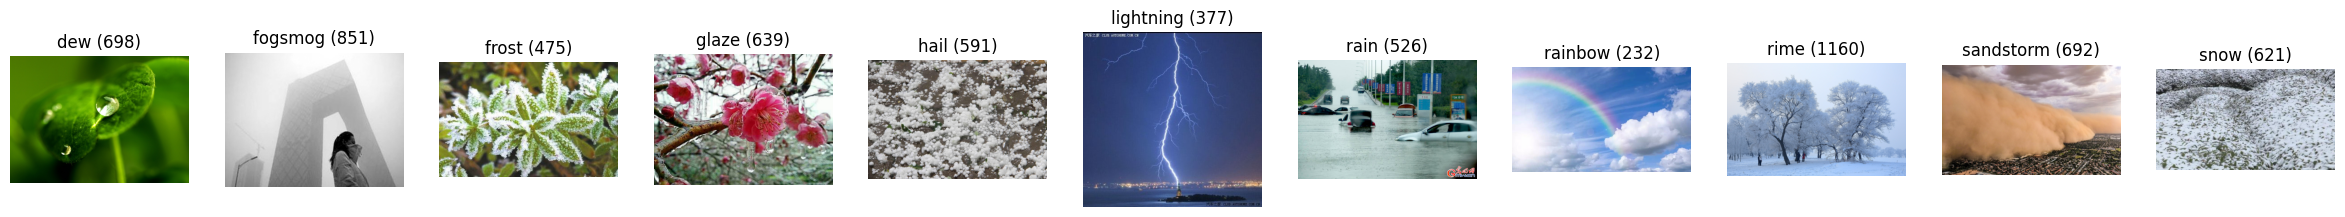

Total number of images: 6862


In [22]:
# 1. Download the dataset
path = kagglehub.dataset_download("jehanbhathena/weather-dataset")
root_path = path + "/dataset"
# 2. Show the number of categories
categories = [d for d in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, d))]
print(f"Number of categories: {len(categories)}")
# 3. Show the first image of each category
total_images = 0
plt.figure(figsize=(30, 10))
for i, category in enumerate(categories):
    category_path = os.path.join(root_path, category)
    files = [f for f in os.listdir(category_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    # Count images in this category
    num_images = len(files)
    total_images += num_images
    # Show first image
    file_path = os.path.join(category_path, files[0])
    img = Image.open(file_path)
    plt.subplot(1, len(categories), i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{category} ({num_images})")
plt.show()
print(f"Total number of images: {total_images}")

In [29]:
# Now we upload the images to MinIO with minimal change in filenames.
for i, category in enumerate(categories):
    category_path = os.path.join(root_path, category)
    files = [f for f in os.listdir(category_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for j, file in enumerate(files):
        file_path = os.path.join(category_path, file)
        # Get file extension
        ext = file_path.split('.')[-1].split('?')[0]
        # Minimal change to filename in MinIO
        object_name = f"temporal-landing/image_{i}_{j}.{ext}"
        # Open file in binary mode and upload
        with open(file_path, "rb") as f:
            s3.upload_fileobj(
                Fileobj=f,
                Bucket="landing-zone",
                Key=object_name,
                ExtraArgs={
                    "Metadata": {
                        "source": "kaggle",
                        "url": "https://www.kaggle.com/datasets/jehanbhathena/weather-dataset",
                        "label": category
                    },
                    "ContentType": f"image/{ext.lower()}"
                }
            )
        print(f"Uploaded {file} to MinIO as {object_name} with metadata")

Uploaded 2208.jpg to MinIO as temporal-landing/image_0_0.jpg with metadata
Uploaded 2209.jpg to MinIO as temporal-landing/image_0_1.jpg with metadata
Uploaded 2210.jpg to MinIO as temporal-landing/image_0_2.jpg with metadata
Uploaded 2211.jpg to MinIO as temporal-landing/image_0_3.jpg with metadata
Uploaded 2212.jpg to MinIO as temporal-landing/image_0_4.jpg with metadata
Uploaded 2213.jpg to MinIO as temporal-landing/image_0_5.jpg with metadata
Uploaded 2214.jpg to MinIO as temporal-landing/image_0_6.jpg with metadata
Uploaded 2215.jpg to MinIO as temporal-landing/image_0_7.jpg with metadata
Uploaded 2216.jpg to MinIO as temporal-landing/image_0_8.jpg with metadata
Uploaded 2217.jpg to MinIO as temporal-landing/image_0_9.jpg with metadata
Uploaded 2218.jpg to MinIO as temporal-landing/image_0_10.jpg with metadata
Uploaded 2219.jpg to MinIO as temporal-landing/image_0_11.jpg with metadata
Uploaded 2220.jpg to MinIO as temporal-landing/image_0_12.jpg with metadata
Uploaded 2221.jpg to M